In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

performance = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

print(nav.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


# Daily Return Analysis

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [4]:
print(nav.head())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


In [5]:
fig = px.histogram(
    nav,
    x="daily_return",
    nbins=100,
    title="Daily Return Distribution"
)

fig.show()

In [6]:
fig.write_image(
    "../reports/charts/daily_return_distribution.png"
)

# CAGR Analysis

In [7]:
cagr_results = []

for code in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == code
    ].sort_values("date")

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    years = (
        (df.iloc[-1]["date"] -
         df.iloc[0]["date"]).days
        / 365
    )

    cagr = (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    )

    cagr_results.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [8]:
import pandas as pd
import numpy as np

In [9]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

print(nav.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [10]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(nav.head())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


In [11]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')


In [12]:
cagr_results = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code]

    start_nav = fund.iloc[0]["nav"]
    end_nav = fund.iloc[-1]["nav"]

    years = (
        (fund.iloc[-1]["date"] -
         fund.iloc[0]["date"]).days
        / 365
    )

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    cagr_results.append(
        [code, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr"]
)

print(cagr_df.head())

   amfi_code      cagr
0     100016  0.026352
1     100025  0.044551
2     100033  0.300997
3     101206  0.235205
4     101207  0.079331


In [13]:
print(cagr_df.shape)

(40, 2)


In [14]:
cagr_df.to_csv(
    "../data/processed/cagr_results.csv",
    index=False
)

print("CAGR results saved successfully")

CAGR results saved successfully


In [15]:
rf = 0.065

sharpe_results = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    annual_return = returns.mean() * 252

    annual_std = returns.std() * np.sqrt(252)

    sharpe = (
        (annual_return - rf)
        / annual_std
    )

    sharpe_results.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

print(sharpe_df.head())

   amfi_code  sharpe_ratio
0     100016     -0.201517
1     100025     -0.567095
2     100033      1.093699
3     101206      1.027213
4     101207      0.162661


In [16]:
print(sharpe_df.shape)

(40, 2)


In [17]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

print("Sharpe ratio saved successfully")

Sharpe ratio saved successfully


In [18]:
sortino_results = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        returns.mean()
        * 252
    )

    sortino = (
        (annual_return - rf)
        / downside_std
    )

    sortino_results.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

print(sortino_df.head())

   amfi_code  sortino_ratio
0     100016      -0.351047
1     100025      -0.941821
2     100033       1.829134
3     101206       1.799563
4     101207       0.276644


In [19]:
print(sortino_df.shape)

(40, 2)


In [20]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

print("Sortino ratio saved successfully")

Sortino ratio saved successfully


In [21]:
print(sortino_df.shape)

(40, 2)


In [22]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

print("Sortino ratio saved successfully")

Sortino ratio saved successfully


In [23]:
print(benchmark.columns)
print(benchmark.head())

Index(['date', 'index_name', 'close_value'], dtype='str')
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [24]:
print(benchmark["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [25]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [26]:
alpha_beta_results = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ][["date","daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[["date","benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 10:

        slope, intercept, r, p, stderr = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = slope
        alpha = intercept * 252

        alpha_beta_results.append(
            [code, alpha, beta]
        )

In [27]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

print(alpha_beta_df.head())

   amfi_code     alpha      beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289


In [28]:
print(alpha_beta_df.shape)

(40, 3)


In [29]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("Alpha Beta CSV saved successfully")

Alpha Beta CSV saved successfully


In [30]:
print(alpha_beta_df.shape)

(40, 3)


In [31]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("Alpha Beta CSV saved successfully")

Alpha Beta CSV saved successfully


In [32]:
mdd_results = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ].sort_values("date")

    running_max = fund["nav"].cummax()

    drawdown = (
        fund["nav"] / running_max
    ) - 1

    max_dd = drawdown.min()

    mdd_results.append(
        [code, max_dd]
    )

mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

print(mdd_df.head())

   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469


In [33]:
print(mdd_df.shape)

(40, 2)


In [34]:
mdd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print("Maximum Drawdown CSV saved")

Maximum Drawdown CSV saved


In [35]:
scorecard = performance.copy()

scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    mdd_df,
    on="amfi_code"
)

In [36]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["mdd_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

KeyError: 'sharpe_ratio'

In [37]:
print(scorecard.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha_x', 'beta_x', 'sharpe_ratio_x',
       'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore',
       'expense_ratio_pct', 'morningstar_rating', 'risk_grade',
       'sharpe_ratio_y', 'alpha_y', 'beta_y', 'max_drawdown', 'return_rank'],
      dtype='str')


In [38]:
print(sharpe_df.columns)
print(alpha_beta_df.columns)
print(mdd_df.columns)

Index(['amfi_code', 'sharpe_ratio'], dtype='str')
Index(['amfi_code', 'alpha', 'beta'], dtype='str')
Index(['amfi_code', 'max_drawdown'], dtype='str')


In [39]:
scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha_x,...,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,sharpe_ratio_y,alpha_y,beta_y,max_drawdown,return_rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,-21.70,14288,1.54,4,Moderate,1.208267,0.232010,-0.031751,-0.150124,26.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,-24.43,1231,0.66,3,Moderate,0.953279,0.198686,-0.026159,-0.118035,34.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,-13.35,19259,1.43,5,Very High,0.945308,0.303370,-0.023196,-0.287060,1.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,-24.78,36061,0.72,4,Very High,-0.057187,0.048824,0.062002,-0.525742,2.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,-2.30,24101,0.77,5,Low,-0.226575,0.056209,-0.006414,-0.043287,38.0


In [40]:
# Create missing ranks

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio_y"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha_y"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["mdd_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

# Calculate final score

scorecard["fund_score"] = (
      scorecard["return_rank"] * 0.30
    + scorecard["sharpe_rank"] * 0.25
    + scorecard["alpha_rank"] * 0.20
    + scorecard["expense_rank"] * 0.15
    + scorecard["mdd_rank"] * 0.10
)

print(
    scorecard[
        ["scheme_name","fund_score"]
    ].head()
)

                                    scheme_name  fund_score
0     SBI Bluechip Fund - Regular Plan - Growth      17.075
1      SBI Bluechip Fund - Direct Plan - Growth      17.900
2    SBI Small Cap Fund - Regular Plan - Growth      10.750
3     SBI Small Cap Fund - Direct Plan - Growth      20.625
4  SBI Magnum Gilt Fund - Regular Plan - Growth      29.300


In [41]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved successfully")

Fund Scorecard saved successfully


In [42]:
print(benchmark["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


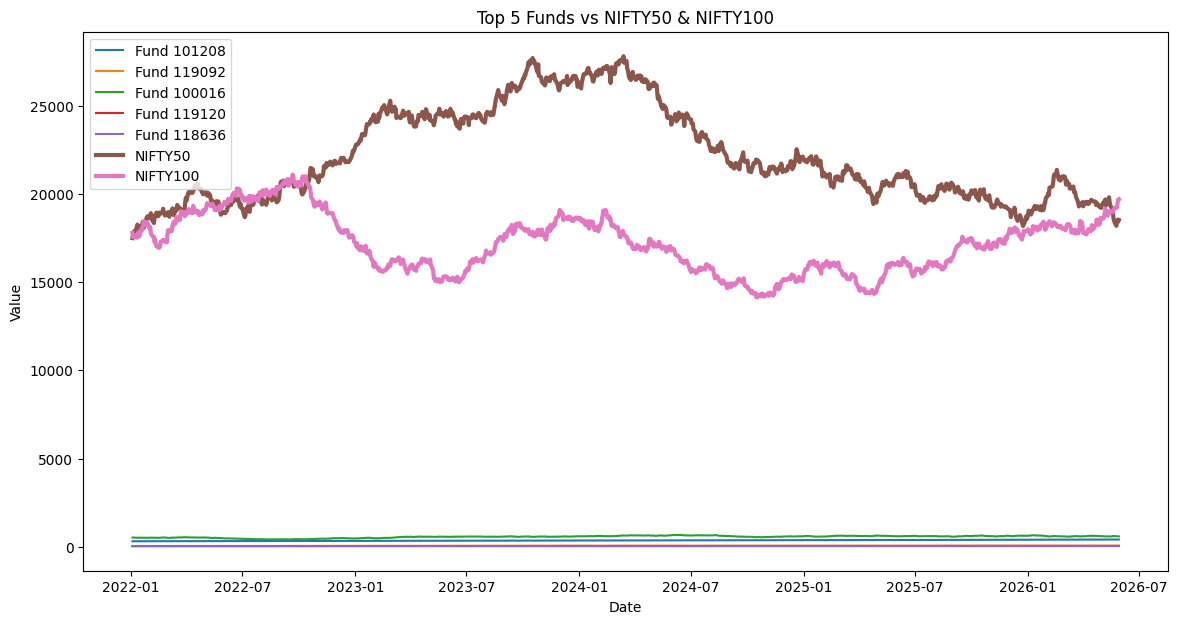

In [48]:


top5 = scorecard.sort_values(
    "fund_score",
    ascending=False
).head(5)

top_codes = top5["amfi_code"].tolist()

plt.figure(figsize=(14,7))

# Plot top 5 funds

for code in top_codes:

    fund = nav[
        nav["amfi_code"] == code
    ].sort_values("date")

    plt.plot(
        fund["date"],
        fund["nav"],
        label=f"Fund {code}"
    )

# NIFTY50

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50["date"] = pd.to_datetime(
    nifty50["date"]
)

plt.plot(
    nifty50["date"],
    nifty50["close_value"],
    linewidth=3,
    label="NIFTY50"
)

# NIFTY100

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    linewidth=3,
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100"
)

plt.xlabel("Date")
plt.ylabel("Value")

plt.legend()

plt.show()

Benchmark chart saved successfully


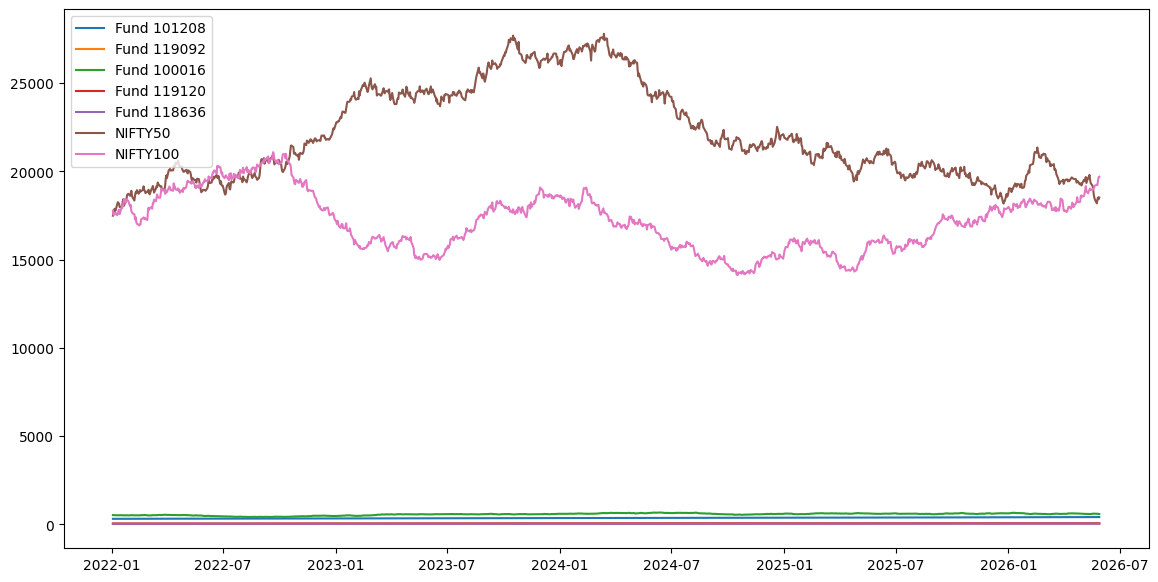

In [49]:
plt.figure(figsize=(14,7))

for code in top_codes:

    fund = nav[
        nav["amfi_code"] == code
    ].sort_values("date")

    plt.plot(
        fund["date"],
        fund["nav"],
        label=f"Fund {code}"
    )

plt.plot(
    nifty50["date"],
    nifty50["close_value"],
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    label="NIFTY100"
)

plt.legend()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    bbox_inches="tight"
)

print("Benchmark chart saved successfully")

In [44]:
import matplotlib.pyplot as plt

In [45]:
print(top_codes)

[101208, 119092, 100016, 119120, 118636]


In [46]:
print(nifty50.head())

NameError: name 'nifty50' is not defined

In [47]:
import pandas as pd
